# Week 7: Classifiers

This notebook applies classification models to predict emotion from extracted audio features. We compare our MiniLearn implementations against scikit-learn as a reference.

## Logistic Regression

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import sys
sys.path.insert(0, str(Path.cwd().parent))
from minilearn.classifiers import LogisticRegression as MLLogisticRegression
from sklearn.linear_model import LogisticRegression as SKLogisticRegression

In [2]:
# Resolve project root from notebook location
NOTEBOOK_DIR = Path.cwd()
if (NOTEBOOK_DIR / 'SER_Project').exists():
    PROJECT_ROOT = NOTEBOOK_DIR / 'SER_Project'
elif NOTEBOOK_DIR.name == 'notebooks' and (NOTEBOOK_DIR.parent / 'pipeline').exists():
    PROJECT_ROOT = NOTEBOOK_DIR.parent
else:
    PROJECT_ROOT = NOTEBOOK_DIR

DATA_DIR = PROJECT_ROOT / 'data'
FEATURES_CSV = DATA_DIR / 'features.csv'

print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'FEATURES_CSV exists: {FEATURES_CSV.exists()}')

PROJECT_ROOT: c:\Users\wblut\Documents\My Projects\Python\CSE 432\Project_CSE432-532\SER_Project
FEATURES_CSV exists: True


In [3]:
if not FEATURES_CSV.exists():
    raise FileNotFoundError(
        f'Missing {FEATURES_CSV}. Run the feature extraction pipeline first (notebook 01 or CLI).'
    )

df = pd.read_csv(FEATURES_CSV)
print(f'Feature table shape: {df.shape}')
print(f'Emotions: {sorted(df["emotion"].unique())}')
print(f'\nEmotion distribution:\n{df["emotion"].value_counts().sort_index()}')

Feature table shape: (1440, 384)
Emotions: ['angry', 'calm', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']

Emotion distribution:
emotion
angry        192
calm         192
disgust      192
fearful      192
happy        192
neutral       96
sad          192
surprised    192
Name: count, dtype: int64


In [4]:
# Prepare data for classification
target_col = 'emotion'
if target_col not in df.columns:
    raise KeyError(f'Expected target column {target_col} in features.csv')

drop_cols = [
    'filepath', 'filename',
    'modality', 'vocal_channel', 'emotion', 'intensity', 'statement',
    'modality_code', 'vocal_channel_code', 'emotion_code', 'statement_code',
    'intensity_code', 'repetition', 'actor_id',
]

feature_cols = [c for c in df.columns if c not in drop_cols]

X = df[feature_cols].copy()
y = df[target_col].copy()

print(f'Features: {X.shape[1]}')
print(f'Rows: {X.shape[0]}')
print(f'Classes: {y.nunique()}')

Features: 370
Rows: 1440
Classes: 8


In [5]:
# Train/test split with stratification to preserve emotion distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

# Standardize features (fit on training data only)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Training set: {X_train_scaled.shape}')
print(f'Test set: {X_test_scaled.shape}')

Training set: (1152, 370)
Test set: (288, 370)


In [6]:
# MiniLearn Logistic Regression
ml_lr = MLLogisticRegression(
    learning_rate=0.01,
    max_iter=500,
    fit_intercept=True,
    l2_penalty=0.0001,
    random_state=42,
    verbose=False,
)
ml_lr.fit(X_train_scaled, y_train)
ml_y_pred = ml_lr.predict(X_test_scaled)

print('MiniLearn LogisticRegression fitted.')
print(f'Accuracy: {ml_lr.score(X_test_scaled, y_test):.4f}')

MiniLearn LogisticRegression fitted.
Accuracy: 0.6042


In [7]:
# Scikit-learn Logistic Regression (for comparison)
sk_lr = SKLogisticRegression(
    max_iter=500,
    penalty='l2',
    C=1e4,  # inverse of l2_penalty
    random_state=42,
    solver='lbfgs',
)
sk_lr.fit(X_train_scaled, y_train)
sk_y_pred = sk_lr.predict(X_test_scaled)

print('Scikit-learn LogisticRegression fitted.')
print(f'Accuracy: {sk_lr.score(X_test_scaled, y_test):.4f}')

c:\Users\wblut\Documents\My Projects\Python\CSE 432\Project_CSE432-532\SER_Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Scikit-learn LogisticRegression fitted.
Accuracy: 0.6597


In [8]:
# Compute metrics for both models
def compute_metrics(y_true, y_pred, model_name):
    """Compute classification metrics."""
    acc = accuracy_score(y_true, y_pred)
    prec_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall_macro = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    
    return {
        'Model': model_name,
        'Accuracy': acc,
        'Precision (macro)': prec_macro,
        'Recall (macro)': recall_macro,
        'F1 (macro)': f1_macro,
    }

metrics_ml = compute_metrics(y_test, ml_y_pred, 'MiniLearn LR')
metrics_sk = compute_metrics(y_test, sk_y_pred, 'Scikit-learn LR')

results_df = pd.DataFrame([metrics_ml, metrics_sk])
print(results_df.to_string(index=False))

          Model  Accuracy  Precision (macro)  Recall (macro)  F1 (macro)
   MiniLearn LR  0.604167           0.599567        0.582827    0.578895
Scikit-learn LR  0.659722           0.678377        0.654521    0.661803


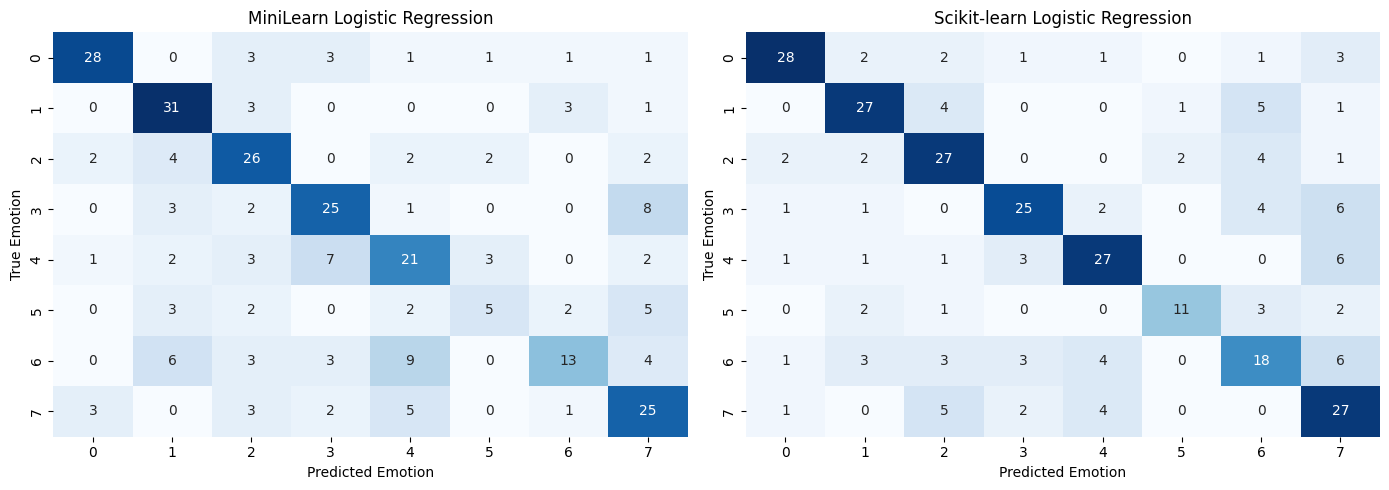

In [9]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_ml = confusion_matrix(y_test, ml_y_pred, labels=sorted(y_test.unique()))
cm_sk = confusion_matrix(y_test, sk_y_pred, labels=sorted(y_test.unique()))

sns.heatmap(cm_ml, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('MiniLearn Logistic Regression')
axes[0].set_ylabel('True Emotion')
axes[0].set_xlabel('Predicted Emotion')

sns.heatmap(cm_sk, annot=True, fmt='d', cmap='Blues', ax=axes[1], cbar=False)
axes[1].set_title('Scikit-learn Logistic Regression')
axes[1].set_ylabel('True Emotion')
axes[1].set_xlabel('Predicted Emotion')

plt.tight_layout()
plt.show()

## Logistic Regression Summary

Both implementations show similar performance on the SER classification task. The confusion matrices reveal which emotions are confused with one another and can guide feature engineering or model tuning in later weeks.

## Decision Tree

## Decision Tree Summary

## k-Nearest-Numbers

## k-Nearest-Numbers Summary

## Naive Bayes

## Naive Bayes Summary